# Climate Change VS Energy Consumption VS Renewable Energy
Question: In the face of climate change, how does weather variability affect Singapore's electrical consumption and will it be able to utilise renewables to recover this energy needs?

### 1. Ask
- 1.1 Background
- 1.2 Hypothesis
- 1.3 Analysis Goal
#### 1.1 Background
In recent decades, the issue of global warming has hit headlines time and time again. Rising sea levels, extreme weather events, food security,. …. They are interlinked long-term issues that come with global warming and will affect each and every single one of us in one way or another. Of these many effects, the most prominent one comes from rising temperatures.

In Singapore, solar panels are installed at the top of HDBs to cut cost and reliance on imported electricity. However, the question of whether it is sufficient to meet our needs arises.

Hence, our analysis aims to measure the differences in energy consumption and energy production during peak demands and account for the variations to determine if energy genereated is able to offset current and future growth in energy demands. If unable, what are the barriers preventing them from doing so and how do we achieve net 0.

- what is currently happening
- severity
- how weather affect electrical consumption and does it affect singapore's path towards net 0 --> weather renewable energy can meet our needs and how much growth is needed to achieve
#### 1.2 Hypothesis
- what question you will address
- what analytical goal do you want to pursue
#### 1.3 Analysis Goal
- what analysis is neeeded:
    - forecasting: electricity consumption growth, weather trend
    - heat map: location anomaly
    - changes in electrical consumption overtime + months/regions and potential reasons why
- quality matric is targetted
- influence on policy makers and researchers

#### 1.4 Requirement Analysis
To tackle the problem, we have to retrieve datasets relating to weather and solar powered energy. Since there are no available datasets for the exact values, estimations have to be made and can be done using housing of different property types.
- data needs to be aligned with historical wewather data at different time and locations
To obtain results that are more accurate, it is desirable to cover different parts within Singapore (North, South, East West) where temperatures and electrical consumption may vary with regions.
Moreover, temperature and rainfall vary in Singapore due to the urban cover 

In [ ]:
# Importing packages 
import pandas as pd
import folium

### 2. Prepare
In this stage, our goal is to retrieve and clean the datasets such that they can be used directly in analysis.

- 2.1. Data Source identification and exploration
- 2.2. Data Retrival (Weather)
- 2.3. Data Retrival (Renewable)
- 2.4. Data Retrival (Energy Usage)
other data sets" https://api-open.data.gov.sg/v2/real-time/api/rainfall

#### 2.2. Data Retrival (Weather)
- Data Source: https://www.weather.gov.sg/climate-historical-daily/

Meterological Service Singapore gives us the data necessary to conduct analysis on the weather. Apart from providing data across different locations and years in Singapore, it also provides rainfall (total, highest- 30min, 60min, 120min), temperature(max, min, mean) and wind(max, mean)

From the website, it gives a list of weather stations names and the data is records (i.e. rainfall, temperature, wind, visibility, historical records, staiton closed). Using this information, we analysed the data that was provided before deciding on which datasets to extract from the website.

After analysing the metadata and ______,

We noticed how some locations did not provide us with any data (provde and show 0 and 1 for each row and columm)

We then went on to filter out the rows that we needed

We removed stations closed since it would not provide anymore data in future 
Also, we removed those locations which did not have historical data since we would be unable to analyse the change across the years

In [10]:
# Overview of weather stations
station = pd.read_csv("stationInfo.csv")
print(station.head())

   S/N Station ID          Current Station Name  Previous Station Name  \
0  NaN        NaN                            NaN                   NaN   
1    1        S07           Macritchie Reservoir                     -   
2    2        S08         Lower Peirce Reservoir                     -   
3    3        S11                    Jalan Bahar  Choa Chu Kang (West)   
4    4        S24  Changi Meteorological Station                Changi   

   Latitude   Longitude Current Observations   Unnamed: 7         Unnamed: 8  \
0       NaN         NaN             Rainfall  Temperature  Relative Humidity   
1  1.341782  103.833873                    1            0                  0   
2  1.370034  103.827037                    1            0                  0   
3  1.374500  103.693800                    0            0                  0   
4  1.367800  103.982300                    1            1                  1   

  Unnamed: 9 Unnamed: 10  Ultraviolet Index (UVI)  Heat Stress  \
0       

In [7]:
# Getting metadata
station.columns
station.info()
station.shape
station.nunique()

<class 'pandas.DataFrame'>
RangeIndex: 121 entries, 0 to 120
Data columns (total 15 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   S/N                       119 non-null    str    
 1   Station ID                118 non-null    str    
 2   Current Station Name      118 non-null    str    
 3   Previous Station Name     118 non-null    str    
 4   Latitude                  118 non-null    float64
 5   Longitude                 118 non-null    float64
 6   Current Observations      119 non-null    str    
 7   Unnamed: 7                119 non-null    str    
 8   Unnamed: 8                119 non-null    str    
 9   Unnamed: 9                119 non-null    str    
 10  Unnamed: 10               119 non-null    str    
 11  Ultraviolet Index (UVI)   118 non-null    float64
 12  Heat Stress               118 non-null    float64
 13  Historical Daily Records  118 non-null    float64
 14  Station Closed       

S/N                         119
Station ID                  118
Current Station Name        116
Previous Station Name        61
Latitude                    118
Longitude                   118
Current Observations          3
Unnamed: 7                    3
Unnamed: 8                    3
Unnamed: 9                    3
Unnamed: 10                   3
Ultraviolet Index (UVI)       2
Heat Stress                   2
Historical Daily Records      2
Station Closed                2
dtype: int64

In [11]:
# Rename columns 
station = station.rename(columns={
    "Current Observations" : "Rainfall",
    "Unnamed: 7": "Temperature",
    "Unnamed: 8": "Humidity",
    "Unnamed: 9": "Wind Speed",
    "Unnamed: 10": "Pressure"
})
# Retrieving all station names that are opened - Removing closed stations 
station = station[station["Station Closed "]!=1]

# Removing stations without historical records
station = station[station["Historical Daily Records"]==1]

# Removing stations that had no data on temperature
station = station[station['Temperature']=='1'] # different data type for this column
#for _, row in station.iterrows():
#    print(row["Latitude"], row["Longitude"])

In [12]:
# Extracting all the locations in station and plotting them on Singapore map to determine if there is a good spread
sg_map = folium.Map(location=[1.352,103.8198],zoom_start=12)
for _, row in station.iterrows():
    folium.Marker(location=[row["Latitude"], row["Longitude"]], popup=row["Latitude"], radius=30,color="red",fill=True, fill_color="red").add_to(sg_map)
sg_map

#### 2.2. Data Retrival (Renewable)

In [13]:
solar =pd.read_excel("solarCapacity.xlsx")
#print(solar.head(35))

In [ ]:
# Making first row as header
solar.columns=solar.iloc[2]

# Drop NA rows and reformat indexing
solar = solar.drop(solar.head(2).index)
solar = solar.drop(solar.tail(25).index)
solar = solar.drop([2,3,5,7])
solar = solar.reset_index(drop=True)
solar.columns.name=None

print(solar)

                                                 NaN   2008 Q4  2009 Q1  \
0                                              Total  0.300425  0.35592   
1                                        Residential   0.04287  0.04791   
2                                    Non-Residential  0.257555  0.30801   
3                            Public Service Agencies      0.07     0.07   
4     Town Councils & Public Housing Common Services    0.0133   0.0133   
5                                     Private Sector  0.174255  0.22471   

    2009 Q2   2009 Q3   2009 Q4   2010 Q1   2010 Q2   2010 Q3   2010 Q4  ...  \
0  0.591192  0.903132  1.849377  2.544725  2.643965  2.949057  3.405177  ...   
1  0.056622  0.063622  0.069412  0.069412  0.074212  0.076212  0.080212  ...   
2   0.53457   0.83951  1.779965  2.475313  2.569753  2.872845  3.324965  ...   
3   0.08668   0.08668   0.11018  0.227525  0.227525  0.257765  0.281285  ...   
4    0.0159    0.0159    0.0159    0.0159    0.0159    0.1677   0.49438  .

#### 2.2. Data Retrival (Energy Usage)
Data Source: https://www.spgroup.com.sg/our-services/utilities/tariff-information

This section determines the average electricity usage for households through estimation.
By using the average consumption of electrictiy (kWh) and estimated total households
This is then compared with the average of residential areas.

In [165]:
solar =pd.read_excel("AverageElectricity.xlsx")
#print(solar.head(10))

In [166]:
# Making first row as header
solar.columns=solar.iloc[0]

# drop first row
solar = solar.drop(0)
solar = solar.drop(solar.tail(3).index)

# Renaname Headers
solar = solar.rename(columns={solar.columns[1]:"022025",solar.columns[2]:"032025",solar.columns[3]:"042025",solar.columns[4]:"052025",solar.columns[5]:"062025",solar.columns[6]:"072025",solar.columns[7]:"082025",solar.columns[8]:"092025",solar.columns[9]:"102025",solar.columns[10]:"12025",solar.columns[11]:"122025",solar.columns[12]:"012026"})
print(solar)

0  Premises Types 022025 032025 042025 052025 062025 072025 082025 092025  \
1      HDB 1-Room    121    119    128    136    150    143    150    136   
2      HDB 2-Room    161    156    169    181    195    190    195    177   
3      HDB 3-Room    231    231    250    265    284    273    280    257   
4      HDB 4-Room    320    309    341    363    390    381    388    358   
5      HDB 5-Room    374    359    399    425    457    450    459    423   
6   HDB Executive    458    445    495    522    562    554    562    520   
7       Apartment    419    417    476    516    548    536    541    513   
8         Terrace    744    714    775    823    881    848    866    817   
9   Semi-Detached    974    960   1031   1080   1173   1123   1121   1072   
10       Bungalow   1872   1904   2016   2154   2244   2175   2168   2190   

0  102025 12025 122025 012026  
1     136   144    127    124  
2     177   188    164    165  
3     259   271    242    239  
4     355   377    334  

In [167]:
solar_t = solar.T

solar_t.columns=solar_t.iloc[0]
solar_t=solar_t[1:]

solar_t.reset_index(inplace=True)
solar_t.rename(columns={"index":"Month"},inplace=True)

solar_t.drop(0)
print(solar_t)

Premises Types       0 HDB 1-Room HDB 2-Room HDB 3-Room HDB 4-Room HDB 5-Room  \
0               022025        121        161        231        320        374   
1               032025        119        156        231        309        359   
2               042025        128        169        250        341        399   
3               052025        136        181        265        363        425   
4               062025        150        195        284        390        457   
5               072025        143        190        273        381        450   
6               082025        150        195        280        388        459   
7               092025        136        177        257        358        423   
8               102025        136        177        259        355        417   
9                12025        144        188        271        377        444   
10              122025        127        164        242        334        392   
11              012026      

#### Data Quality Considerations
- completeness
- interpretabiility

### Processing
Given our overarching goal is to determine whether the renewable energy is sufficient to meet our energy demands, we apply ___
- DS1: Weather - determining 
- DS2: Energy Produced from Solar
- DS3: Energy Usage across different flats

- detect anomlay, 

Index([              0,    'HDB 1-Room',    'HDB 2-Room',    'HDB 3-Room',
          'HDB 4-Room',    'HDB 5-Room', 'HDB Executive',     'Apartment',
             'Terrace', 'Semi-Detached',      'Bungalow'],
      dtype='object', name='Premises Types')


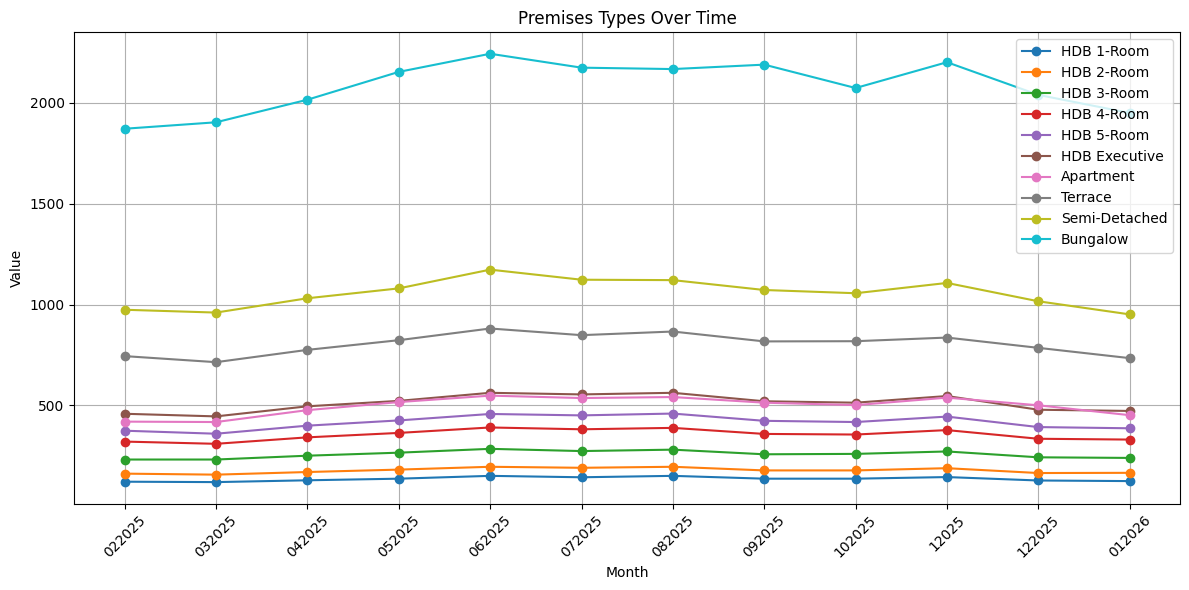

In [ ]:
import matplotlib.pyplot as plt
# Descriptive Analytics
# Patterns across the year - monthly/seasonal trends , peak, variation
print(solar_t.columns)

# Rename the first column (month column) to 'Month'
solar_t.rename(columns={solar_t.columns[0]: 'Month'}, inplace=True)

# Convert Month to string
solar_t['Month'] = solar_t['Month'].astype(str)

# Convert all other columns to numeric
cols = solar_t.columns[1:]
solar_t[cols] = solar_t[cols].apply(pd.to_numeric)

# Plot each Premises Type over time
plt.figure(figsize=(12,6))
for col in cols:
    plt.plot(solar_t['Month'], solar_t[col], marker='o', label=col)

plt.xlabel("Month")
plt.ylabel("Value")
plt.title("Premises Types Over Time")
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# clustering between similar consumption behaviours



from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import pandas as pd

# Transpose so Premises Types are rows
df_features = solar_t.set_index('Month').T

# Scale data
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df_features)

# KMeans clustering (choose number of clusters, e.g., 3)
kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(scaled_data)

# Add cluster info
df_features['Cluster'] = clusters
print(df_features)


# M2
df_months = solar_t.copy()
df_months.set_index('Month', inplace=True)

# Scale
scaled_months = scaler.fit_transform(df_months)

# KMeans clustering
month_clusters = kmeans.fit_predict(scaled_months)

df_months['Cluster'] = month_clusters
print(df_months)

# M3
import pmdarima as pm

# Forecasting HDB 3-Room prices
series = solar_t['HDB 3-Room'].astype(float)

# Fit auto ARIMA
model = pm.auto_arima(series, seasonal=True, m=12)  # monthly data, yearly seasonality

# Forecast next 6 months
forecast = model.predict(n_periods=6)
print(forecast)


# M4

from sklearn.ensemble import RandomForestRegressor
import numpy as np

# Use lag features for supervised learning
df_ml = solar_t.copy()
df_ml['HDB3_Lag1'] = df_ml['HDB 3-Room'].shift(1)
df_ml['HDB3_Lag2'] = df_ml['HDB 3-Room'].shift(2)
df_ml.dropna(inplace=True)

X = df_ml[['HDB3_Lag1','HDB3_Lag2']]
y = df_ml['HDB 3-Room']

model = RandomForestRegressor()
model.fit(X,y)

# Predict next month using last two months
last_vals = np.array(df_ml[['HDB3_Lag1','HDB3_Lag2']].iloc[-1]).reshape(1,-1)
pred_next = model.predict(last_vals)
print(pred_next)

In [ ]:
# using temperature to esimate average irradiance
# Assumptions
P_rated = 300  # W per panel
temp_coefficient = 0.004  # 0.4% per °C
T_ambient = 35  # °C (example)
T_cell = T_ambient + 20  # °C, rough estimate

# Efficiency factor
efficiency_factor = 1 - temp_coefficient * (T_cell - 25)

# Assume average irradiance factor (e.g., 5 kWh/m²/day normalized to 1)
irradiance_factor = 1  # placeholder if unknown

# Estimated power
P_est = P_rated * irradiance_factor * efficiency_factor
print("Estimated power per panel (W):", P_est)

from sklearn.linear_model import LinearRegression
import pandas as pd

# Example historical data
df = pd.DataFrame({
    "Temperature": [25, 30, 35, 28, 32],
    "Energy": [280, 270, 260, 275, 265]  # measured kWh
})

X = df[["Temperature"]]
y = df["Energy"]

model = LinearRegression()
model.fit(X, y)

# Predict energy for 33°C
predicted_energy = model.predict([[33]])
print(predicted_energy)